<a href="https://colab.research.google.com/github/rashmitha-fernando/Machine-Learning-/blob/main/B13_ML_Rashmitha_Fernando_370.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing Libraries and Environment Set Up
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#Loading the data set
car_data = pd.read_csv("/content/car_price_dataset(in).csv")

# Displaying the first 5 records
car_data.head(5)

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
0,1,535651,798186,3,78945,1,2,14,177,73,123,351318.0
1,2,591911,861056,6,117220,5,9,9,148,74,95,285001.5
2,3,686990,770762,2,132538,2,8,15,181,53,97,215386.0
3,4,573999,722381,4,101065,4,3,11,197,54,116,244295.5
4,5,691388,811335,6,61559,3,9,12,160,53,105,531114.5


In [ ]:
#Checking for missing values
car_data.isnull().sum()

,0
v.id,0
on road old,0
on road now,0
years,0
km,0
rating,0
condition,0
economy,0
top speed,0
hp,0


We can see that currently there are no missing values in this given data set.

If there were missing values they could be handled in 3 ways:
1. If the data set is large - drop the entire row containing with missing value
2. If the data set is small - replace the missing value with the clomun mean or median

In [ ]:
# Basic EDA

# Summary statistics
car_data.describe()


,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.00000
mean,500.500000,601648.286000,799131.3970,4.561000,100274.430000,2.988000,5.592000,11.625000,166.89300,84.54600,103.423000,308520.24250
std,288.819436,58407.246204,57028.9502,1.719079,29150.463233,1.402791,2.824449,2.230549,19.28838,20.51694,21.058716,126073.25915
min,1.000000,500265.000000,700018.0000,2.000000,50324.000000,1.000000,1.000000,8.000000,135.00000,50.00000,68.000000,28226.50000
25%,250.750000,548860.500000,750997.7500,3.000000,74367.500000,2.000000,3.000000,10.000000,150.00000,67.00000,85.000000,206871.75000
50%,500.500000,601568.000000,798168.0000,5.000000,100139.500000,3.000000,6.000000,12.000000,166.00000,84.00000,104.000000,306717.75000
75%,750.250000,652267.250000,847563.2500,6.000000,125048.000000,4.000000,8.000000,13.000000,184.00000,102.00000,121.000000,414260.87500
max,1000.000000,699859.000000,899797.0000,7.000000,149902.000000,5.000000,10.000000,15.000000,200.00000,120.00000,140.000000,584267.50000


Here we can see a full summary on all the features available listing their Max, Min, standard Deviation, Quartiles, Mean and count


In [ ]:
# Structure of the dataset
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   v.id           1000 non-null   int64  
 1   on road old    1000 non-null   int64  
 2   on road now    1000 non-null   int64  
 3   years          1000 non-null   int64  
 4   km             1000 non-null   int64  
 5   rating         1000 non-null   int64  
 6   condition      1000 non-null   int64  
 7   economy        1000 non-null   int64  
 8   top speed      1000 non-null   int64  
 9   hp             1000 non-null   int64  
 10  torque         1000 non-null   int64  
 11  current price  1000 non-null   float64
dtypes: float64(1), int64(11)
memory usage: 93.9 KB


This displays all available features, there count and its data type

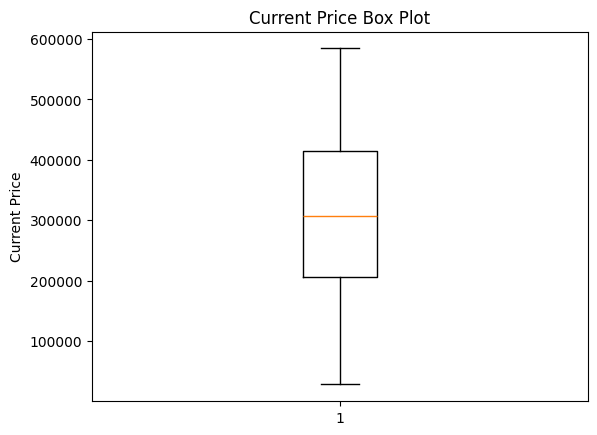

In [ ]:
# Box Plot of Current Price
plt.boxplot(car_data['current price'])
plt.title("Current Price Box Plot")
plt.ylabel("Current Price")
plt.show()

No Outliers are visible in the Boxplot visualization as there are no datapoints visible outside the interquartile range (plots whiskers)

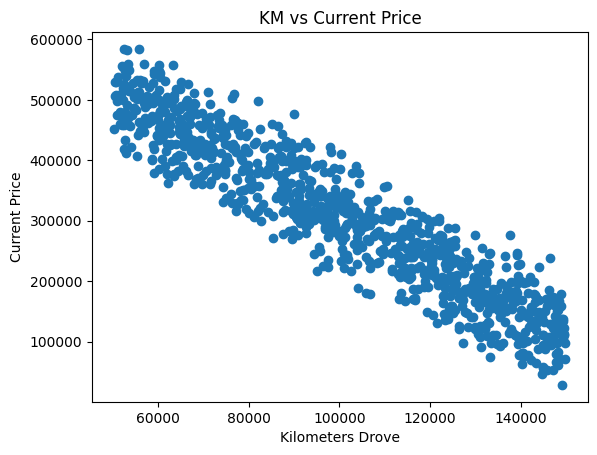

In [ ]:
# Scatter Plot of KM vs Current Price
plt.scatter(car_data['km'], car_data['current price'])
plt.xlabel("Kilometers Drove")
plt.ylabel("Current Price")
plt.title("KM vs Current Price")
plt.show()

In [ ]:
# Feature Selection
X = car_data[["years", "km", "rating", "condition", "economy", "top speed", "hp", "torque"]]
Y = car_data["current price"]

In [ ]:
# Splitting the dataset into 80/20 Training and Testing
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [ ]:
#Trainign linear regression Model
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Evaluating the Linear Regression Model
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 1762071864.7650616
R2 Score: 0.8951832309082719


R² Score = 0.895
This means the model explains about 89.5% of the variance in current car prices using the features selected (years, km, rating, condition, economy, top speed, hp, torque).

R² is close to 1 and indicates a strong fit.

Mean Squared Error = 1,762,071,864.77
MSE value also seems to be on the low side.

Although the given 'Linear Regression model' seems to be a strong fit we can test the same data on a 'Random Forest model' and compare their performances for a definitive answer.

In [ ]:
#Training Random Forest Model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Evaluating the Linear Regression Model
y_pred_rf = rf_model.predict(x_test)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forrest Mean Squared Error:", rf_mse)
print("Random Forrest R2 Score:", rf_r2)

Random Forrest Mean Squared Error: 1897890752.582892
Random Forrest R2 Score: 0.8871040502077758


It is clear that the 'Random Forrest' Model has a higher MSE value and a lower R2 score when compared with the 'Linear Regression' model.

This makes it certain that the 'Linear Regrssion Model' is the best fit model for this use case.

In [ ]:
# Predicting price for a new car using Linear Regression
new_car = pd.DataFrame([[5, 80000, 4, 8, 14, 180, 95, 120]], columns=X.columns)
predicted_price = model.predict(new_car)
print("Predicted Current Price:", predicted_price[0])

Predicted Current Price: 398402.0814799134


"The model predicts a current price of approximately 398,402.081 for a 5-year-old car with 80,000 km, rating 4, condition 8, economy 14, top speed 180, 95 hp, and 120 torque."